# Configurable rolling seizure-onset forecasting from scalp EEG

This executed notebook trains a discrete-time hazard model directly from
EDF scalp EEG. It keeps exactly **two minutes of past EEG context** and,
at each reading, predicts seizure onset over a configurable future
horizon.

User-facing parameters:

- `M_MINUTES` (`m`): first reading is `m` minutes before onset.
- `R_MINUTES` (`r`): future prediction horizon at every reading.
- `I_SECONDS` (`i`): reading interval and future-bin width.
- Output bins per reading: `r × 60 / i`.
- Readings per seizure, including onset: `m × 60 / i + 1`.

The seizure at the onset-time reading has already reached its boundary,
so that final forecast is retained because it was explicitly requested,
but it is not used as a future-onset training target. This is an
exploratory research model, not a clinical device.


In [1]:
from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "rolling_seizure_forecasting.py").exists():
    candidates = list(NOTEBOOK_DIR.rglob("rolling_seizure_forecasting.py"))
    if len(candidates) != 1:
        raise FileNotFoundError(
            "Run this notebook from its scripts directory or repository root."
        )
    NOTEBOOK_DIR = candidates[0].parent
sys.path.insert(0, str(NOTEBOOK_DIR))

import rolling_seizure_forecasting as rsf

# Change these three values and rerun all cells.
M_MINUTES = 5.0
R_MINUTES = 5.0
I_SECONDS = 5
RANDOM_SEED = 42
CONTEXT_SECONDS = 120  # fixed by design

m_seconds = int(round(M_MINUTES * 60))
r_seconds = int(round(R_MINUTES * 60))
if not np.isclose(m_seconds, M_MINUTES * 60):
    raise ValueError("M_MINUTES must resolve to a whole number of seconds.")
if not np.isclose(r_seconds, R_MINUTES * 60):
    raise ValueError("R_MINUTES must resolve to a whole number of seconds.")

config = rsf.ForecastConfig(
    bin_seconds=I_SECONDS,
    horizon_seconds=r_seconds,
    context_seconds=CONTEXT_SECONDS,
    pre_onset_seconds=m_seconds,
    random_seed=RANDOM_SEED,
)
config.validate()
paths = rsf.project_paths(NOTEBOOK_DIR)
paths["processed"].mkdir(parents=True, exist_ok=True)
paths["results"].mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

parameter_table = pd.DataFrame(
    {
        "symbol": ["m", "r", "i", "context", "r/i bins", "readings"],
        "value": [
            f"{M_MINUTES:g} min",
            f"{R_MINUTES:g} min",
            f"{I_SECONDS} s",
            f"{CONTEXT_SECONDS} s",
            config.n_bins,
            config.reading_count,
        ],
        "meaning": [
            "first reading before seizure onset",
            "future horizon at every reading",
            "reading step and future-bin width",
            "causal EEG history retained",
            "probability bins per reading",
            "from -m through onset, inclusive",
        ],
    }
)
print(f"Module version: {rsf.MODULE_VERSION}")
display(parameter_table)


Module version: 3.1.0


,symbol,value,meaning
0,m,5 min,first reading before seizure onset
1,r,5 min,future horizon at every reading
2,i,5 s,reading step and future-bin width
3,context,120 s,causal EEG history retained
4,r/i bins,60,probability bins per reading
5,readings,61,"from -m through onset, inclusive"


## Formulation and loss

For reading time \(t\), the two-minute EEG context is
\(X_t = EEG[t-120,t)\). The model estimates discrete hazards
\(h_k(X_t)\) for \(K=r/i\) future intervals. These are converted into
a coherent probability mass function

\[
p_k=h_k\prod_{j<k}(1-h_j),\qquad
p_{\mathrm{no\ event}}=\prod_{j=1}^{K}(1-h_j).
\]

Therefore \(\sum_k p_k+p_{\mathrm{no\ event}}=1\). Training minimizes
weighted binary cross-entropy over at-risk person-period rows, which is
the discrete-time survival likelihood. It handles both an observed
onset bin and a right-censored/no-event horizon.

The peak-bin matrix is a lossy summary. The complete distribution and
explicit no-event probability are saved as CSV and should be used for
calibration or scientific evaluation.


## Exact reproducible seizure allocation

In [2]:
edf_files = sorted(paths["raw"].rglob("*.edf"))
saved_manifest_path = paths["results"] / "episode_manifest.csv"
if paths["event_inventory"].exists():
    events = rsf.load_event_inventory(paths["event_inventory"])
    event_source = paths["event_inventory"]
elif saved_manifest_path.exists():
    previous_manifest = pd.read_csv(saved_manifest_path)
    previous_positive = previous_manifest.loc[
        previous_manifest["episode_type"].eq("preictal")
    ].copy()
    events = pd.DataFrame(
        {
            "patient_id": previous_positive["patient_id"],
            "event_id": previous_positive["source_event_id"],
            "recording": previous_positive["recording"],
            "onset_seconds": previous_positive["event_onset_seconds"],
            "seizure_duration_seconds": 0.0,
            "eligible_preictal": True,
        }
    ).drop_duplicates("event_id").reset_index(drop=True)
    event_source = saved_manifest_path
else:
    raise FileNotFoundError(
        "Neither event_inventory.csv nor a saved audited manifest exists."
    )

base_manifest = rsf.build_episode_manifest(events, paths["raw"], config)
manifest, seizure_allocation = rsf.assign_requested_splits(
    base_manifest,
    rsf.REQUESTED_SEIZURE_SPLITS,
    random_seed=RANDOM_SEED,
)

expected_counts = (
    pd.DataFrame(rsf.REQUESTED_SEIZURE_SPLITS)
    .fillna(0)
    .astype(int)
    .rename_axis("patient_id")
    .reset_index()
)
actual_counts = (
    seizure_allocation.groupby(["patient_id", "dataset_split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
split_count_check = expected_counts.merge(
    actual_counts,
    on="patient_id",
    how="outer",
    suffixes=("_expected", "_actual"),
).fillna(0)
for split_name in ("train", "validation", "test"):
    assert (
        split_count_check[f"{split_name}_expected"]
        == split_count_check[f"{split_name}_actual"]
    ).all(), split_count_check
assert seizure_allocation["source_event_id"].nunique() == 47
assert seizure_allocation.groupby("dataset_split").size().to_dict() == {
    "test": 8,
    "train": 35,
    "validation": 4,
}
assert not seizure_allocation["source_event_id"].duplicated().any()

manifest.to_csv(paths["results"] / "episode_manifest.csv", index=False)
seizure_allocation.to_csv(
    paths["results"] / "seizure_split_allocation.csv", index=False
)
print(f"Event metadata source: {event_source}")
print(f"EDF files found: {len(edf_files)}")
display(split_count_check.style.hide(axis="index"))
display(seizure_allocation.style.hide(axis="index"))


Event metadata source: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast\episode_manifest.csv
EDF files found: 41


patient_id,train_expected,validation_expected,test_expected,test_actual,train_actual,validation_actual
PN00,4,0,1,1,4,0
PN01,2,0,0,0,2,0
PN03,2,0,0,0,2,0
PN05,2,0,1,1,2,0
PN06,4,0,1,1,4,0
PN07,1,0,0,0,1,0
PN09,2,0,1,1,2,0
PN10,8,1,1,1,8,1
PN11,1,0,0,0,1,0
PN12,3,0,1,1,3,0


dataset_split,patient_id,selection_rank,source_event_id,episode_id,recording
test,PN00,1,PN00_S01,PN00_S01_preictal,PN00-1.edf
test,PN05,1,PN05_S02,PN05_S02_preictal,PN05-3.edf
test,PN06,1,PN06_S04,PN06_S04_preictal,PN06-4.edf
test,PN09,1,PN09_S02,PN09_S02_preictal,PN09-2.edf
test,PN10,1,PN10_S03,PN10_S03_preictal,PN10-3.edf
test,PN12,1,PN12_S04,PN12_S04_preictal,PN12-4.edf
test,PN13,1,PN13_S03,PN13_S03_preictal,PN13-3.edf
test,PN17,1,PN17_S02,PN17_S02_preictal,PN17-2.edf
train,PN00,1,PN00_S05,PN00_S05_preictal,PN00-5.edf
train,PN00,2,PN00_S03,PN00_S03_preictal,PN00-3.edf


The split is **seizure-disjoint**, not patient-disjoint, because the
requested quotas intentionally place PN00, PN05, PN06, PN09, PN10,
PN12, PN13, PN14, PN16, and PN17 in more than one group. No seizure is
reused, but patient-specific signal characteristics can leak across
groups; test performance must be interpreted with that limitation.


## EDF feature extraction with two-minute causal memory

In [3]:
cache_tag = (
    f"m{config.pre_onset_seconds}_r{config.horizon_seconds}"
    f"_i{config.bin_seconds}_v{rsf.FEATURE_CACHE_VERSION}"
)
cache_csv = paths["processed"] / f"landmark_features_{cache_tag}.csv"
cache_metadata = paths["processed"] / f"landmark_features_{cache_tag}.json"
started = time.time()
landmarks = rsf.build_landmark_dataset(
    manifest,
    cache_csv=cache_csv,
    cache_metadata_json=cache_metadata,
    config=config,
    force=False,
    verbose=False,
)
feature_seconds = time.time() - started
expected_rows = len(manifest) * config.pre_onset_steps
feature_checks = pd.DataFrame(
    {
        "check": [
            "expected landmark rows",
            "finite model features",
            "two outcome classes",
            "every episode has m/i trainable readings",
            "exactly 120 seconds of EEG context",
        ],
        "passed": [
            len(landmarks) == expected_rows,
            np.isfinite(
                landmarks[rsf.MODEL_FEATURE_COLUMNS].to_numpy()
            ).all(),
            landmarks["has_event_in_horizon"].nunique() == 2,
            landmarks.groupby("episode_id")
            .size()
            .eq(config.pre_onset_steps)
            .all(),
            config.context_seconds == 120,
        ],
    }
)
assert feature_checks["passed"].all(), feature_checks
print(
    f"Feature table: {len(landmarks):,} rows; "
    f"{len(rsf.MODEL_FEATURE_COLUMNS)} EEG features; "
    f"{feature_seconds:.1f} seconds"
)
display(feature_checks)


Feature table: 5,640 rows; 56 EEG features; 0.0 seconds


,check,passed
0,expected landmark rows,True
1,finite model features,True
2,two outcome classes,True
3,every episode has m/i trainable readings,True
4,exactly 120 seconds of EEG context,True


## Train, validate, and test

In [4]:
train, validation, test, split = rsf.split_by_assignment(landmarks)
split_rows = []
for split_name, frame in [
    ("train", train),
    ("validation", validation),
    ("test", test),
]:
    split_rows.append(
        {
            "split": split_name,
            "seizures": frame.loc[
                frame["episode_type"].eq("preictal"), "episode_id"
            ].nunique(),
            "interictal controls": frame.loc[
                frame["episode_type"].eq("interictal"), "episode_id"
            ].nunique(),
            "landmarks": len(frame),
            "patients": frame["patient_id"].nunique(),
        }
    )
split_summary = pd.DataFrame(split_rows)
assert split_summary.set_index("split")["seizures"].to_dict() == {
    "train": 35,
    "validation": 4,
    "test": 8,
}

started = time.time()
model = rsf.fit_hazard_model(train, config)
training_seconds = time.time() - started

# Validation is used for warning-threshold selection; test remains held out.
(
    validation_predictions,
    validation_metrics,
    validation_patient_metrics,
    _,
    _,
) = rsf.evaluate_forecasts(
    model,
    train,
    validation,
    warning_time_target=config.warning_time_target,
    config=config,
)
(
    test_predictions,
    test_metrics,
    test_patient_metrics,
    warning_threshold,
    validation_warning_curve,
) = rsf.evaluate_forecasts(
    model,
    validation,
    test,
    warning_time_target=config.warning_time_target,
    config=config,
)

hazards_check, pmf_check, no_event_check = (
    rsf.predict_horizon_distribution(model, test.head(32), config)
)
invariants = pd.Series(
    rsf.probability_invariants(
        hazards_check, pmf_check, no_event_check
    ),
    name="passed",
).to_frame()
assert invariants["passed"].all(), invariants

display(split_summary.style.hide(axis="index"))
print(
    f"Model trained only on the train split in {training_seconds:.1f} seconds; "
    f"boosting iterations: {model.n_iter_}"
)
display(Markdown("### Validation metrics"))
display(validation_metrics.style.format({"value": "{:.4f}"}))
display(Markdown("### Held-out test metrics"))
display(test_metrics.style.format({"value": "{:.4f}"}))
display(invariants)


split,seizures,interictal controls,landmarks,patients
train,35,35,4200,13
validation,4,4,480,4
test,8,8,960,8


Model trained only on the train split in 42.4 seconds; boosting iterations: 120


### Validation metrics

,metric,value,interpretation
0,negative log likelihood,2.9645,Lower is better; proper score for the observed bin/no-event class.
1,multicategory Brier score,0.7576,Lower is better; probability error across 60 bins plus no-event.
2,multicategory Brier skill score,-0.0158,Above 0 improves on the development-set class-frequency forecast.
3,integrated survival Brier score,0.1609,Lower is better; mean survival-probability error across 5-minute horizon.
4,5-minute AUROC,0.7091,Discrimination only; does not assess calibration.
5,5-minute average precision,0.6862,Ranking metric sensitive to event prevalence.
6,conditional timing MAE (seconds),73.9014,Error of expected onset time among seizure landmarks.
7,seizure sensitivity,0.2500,Fraction of seizure episodes with at least one warning.
8,time in warning,0.0396,Fraction of evaluated 5-second landmarks under warning.
9,false alarms per hour,6.0000,Rising warning edges in interictal episodes per monitored hour.


### Held-out test metrics

,metric,value,interpretation
0,negative log likelihood,3.7283,Lower is better; proper score for the observed bin/no-event class.
1,multicategory Brier score,0.9704,Lower is better; probability error across 60 bins plus no-event.
2,multicategory Brier skill score,-0.3010,Above 0 improves on the development-set class-frequency forecast.
3,integrated survival Brier score,0.2534,Lower is better; mean survival-probability error across 5-minute horizon.
4,5-minute AUROC,0.2824,Discrimination only; does not assess calibration.
5,5-minute average precision,0.4370,Ranking metric sensitive to event prevalence.
6,conditional timing MAE (seconds),74.2883,Error of expected onset time among seizure landmarks.
7,seizure sensitivity,0.5000,Fraction of seizure episodes with at least one warning.
8,time in warning,0.1562,Fraction of evaluated 5-second landmarks under warning.
9,false alarms per hour,13.5000,Rising warning edges in interictal episodes per monitored hour.


,passed
hazards_are_probabilities,True
pmf_is_nonnegative,True
no_event_is_probability,True
mass_sums_to_one,True
survival_is_monotone,True


In [5]:
validation_predictions.to_csv(
    paths["results"] / "validation_landmark_probabilities.csv", index=False
)
test_predictions.to_csv(
    paths["results"] / "test_landmark_probabilities.csv", index=False
)
validation_metrics.to_csv(
    paths["results"] / "validation_metrics.csv", index=False
)
test_metrics.to_csv(paths["results"] / "test_metrics.csv", index=False)
validation_patient_metrics.to_csv(
    paths["results"] / "validation_patient_metrics.csv", index=False
)
test_patient_metrics.to_csv(
    paths["results"] / "test_patient_metrics.csv", index=False
)
validation_warning_curve.to_csv(
    paths["results"] / "validation_warning_curve.csv", index=False
)
model_path = rsf.save_model_bundle(
    paths["results"] / "rolling_discrete_hazard_model.joblib",
    model,
    config,
    warning_threshold,
    split,
    test_metrics,
)
print(f"Saved model: {model_path}")


Saved model: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast\rolling_discrete_hazard_model.joblib


## Every requested reading and the peak-bin matrix

In [6]:
started = time.time()
reading_probabilities, peak_readings, peak_matrix = (
    rsf.build_seizure_reading_forecasts(
        model,
        manifest,
        landmarks,
        config,
        verbose=False,
    )
)
forecast_seconds = time.time() - started

test_event_ids = seizure_allocation.loc[
    seizure_allocation["dataset_split"].eq("test"), "source_event_id"
].tolist()
test_peak_matrix = peak_matrix[
    ["reading_index", "minutes_before_onset"] + test_event_ids
].copy()

reading_probabilities.to_csv(
    paths["results"] / "all_seizure_reading_probabilities.csv",
    index=False,
)
peak_readings.to_csv(
    paths["results"] / "all_seizure_peak_readings.csv", index=False
)
peak_matrix.to_csv(
    paths["results"] / "all_seizure_peak_bin_matrix.csv", index=False
)
test_peak_matrix.to_csv(
    paths["results"] / "test_peak_bin_matrix.csv", index=False
)

assert len(peak_readings) == 47 * config.reading_count
assert len(reading_probabilities) == (
    47 * config.reading_count * config.n_bins
)
assert peak_matrix.shape == (config.reading_count, 47 + 2)
assert (
    peak_readings.groupby("source_event_id")
    .size()
    .eq(config.reading_count)
    .all()
)
assert peak_readings["peak_bin"].between(1, config.n_bins).all()
mass_check = (
    reading_probabilities.groupby(
        ["source_event_id", "reading_index"], sort=False
    )["onset_probability"]
    .sum()
    .reset_index(name="event_mass")
    .merge(
        peak_readings[
            [
                "source_event_id",
                "reading_index",
                "no_event_probability",
            ]
        ],
        on=["source_event_id", "reading_index"],
        validate="one_to_one",
    )
)
assert np.allclose(
    mass_check["event_mass"] + mass_check["no_event_probability"],
    1.0,
    atol=1e-8,
)
print(
    f"Forecasted {len(peak_readings):,} readings and "
    f"{len(reading_probabilities):,} bin probabilities in "
    f"{forecast_seconds:.1f} seconds."
)
print("Each matrix entry is (highest-probability future bin, probability).")
display(test_peak_matrix.style.hide(axis="index"))


Forecasted 2,867 readings and 172,020 bin probabilities in 15.5 seconds.
Each matrix entry is (highest-probability future bin, probability).


reading_index,minutes_before_onset,PN00_S01,PN05_S02,PN06_S04,PN09_S02,PN10_S03,PN12_S04,PN13_S03,PN17_S02
0,5.000000,"(60, 0.009855)","(60, 0.004699)","(60, 0.018447)","(10, 0.033986)","(55, 0.008813)","(60, 0.007981)","(60, 0.009918)","(60, 0.011219)"
1,4.916667,"(60, 0.006079)","(60, 0.004729)","(60, 0.017360)","(57, 0.023998)","(60, 0.011088)","(60, 0.007816)","(60, 0.006949)","(60, 0.020036)"
2,4.833333,"(60, 0.005767)","(60, 0.005115)","(60, 0.013572)","(57, 0.025094)","(60, 0.012310)","(11, 0.005550)","(60, 0.005331)","(60, 0.023181)"
3,4.750000,"(60, 0.005960)","(60, 0.005107)","(60, 0.011462)","(57, 0.028691)","(60, 0.010688)","(60, 0.004581)","(20, 0.004894)","(60, 0.022972)"
4,4.666667,"(60, 0.008550)","(60, 0.004102)","(60, 0.009220)","(43, 0.034522)","(60, 0.009852)","(60, 0.006567)","(60, 0.005792)","(60, 0.013960)"
5,4.583333,"(56, 0.023308)","(60, 0.004101)","(60, 0.007944)","(39, 0.032851)","(56, 0.009518)","(60, 0.008501)","(60, 0.006442)","(60, 0.008879)"
6,4.500000,"(40, 0.022129)","(60, 0.005456)","(60, 0.007949)","(39, 0.041756)","(60, 0.008420)","(60, 0.006316)","(20, 0.009604)","(60, 0.008443)"
7,4.416667,"(23, 0.018496)","(60, 0.005500)","(60, 0.007389)","(42, 0.043876)","(60, 0.011509)","(55, 0.014707)","(16, 0.012938)","(60, 0.010764)"
8,4.333333,"(23, 0.018861)","(60, 0.004838)","(60, 0.006819)","(43, 0.035015)","(60, 0.011583)","(55, 0.013823)","(6, 0.012982)","(60, 0.008544)"
9,4.250000,"(53, 0.021401)","(60, 0.004440)","(60, 0.008254)","(39, 0.039650)","(60, 0.011541)","(60, 0.015707)","(16, 0.013300)","(60, 0.020584)"


## Probability graphs

Each heatmap row is one requested reading, from `m` minutes before onset
through the onset boundary. Each column is one of the `r/i` future
intervals. Thus every reading's full probability graph is visible,
while the black line traces the maximum-probability bin used in the
matrix.


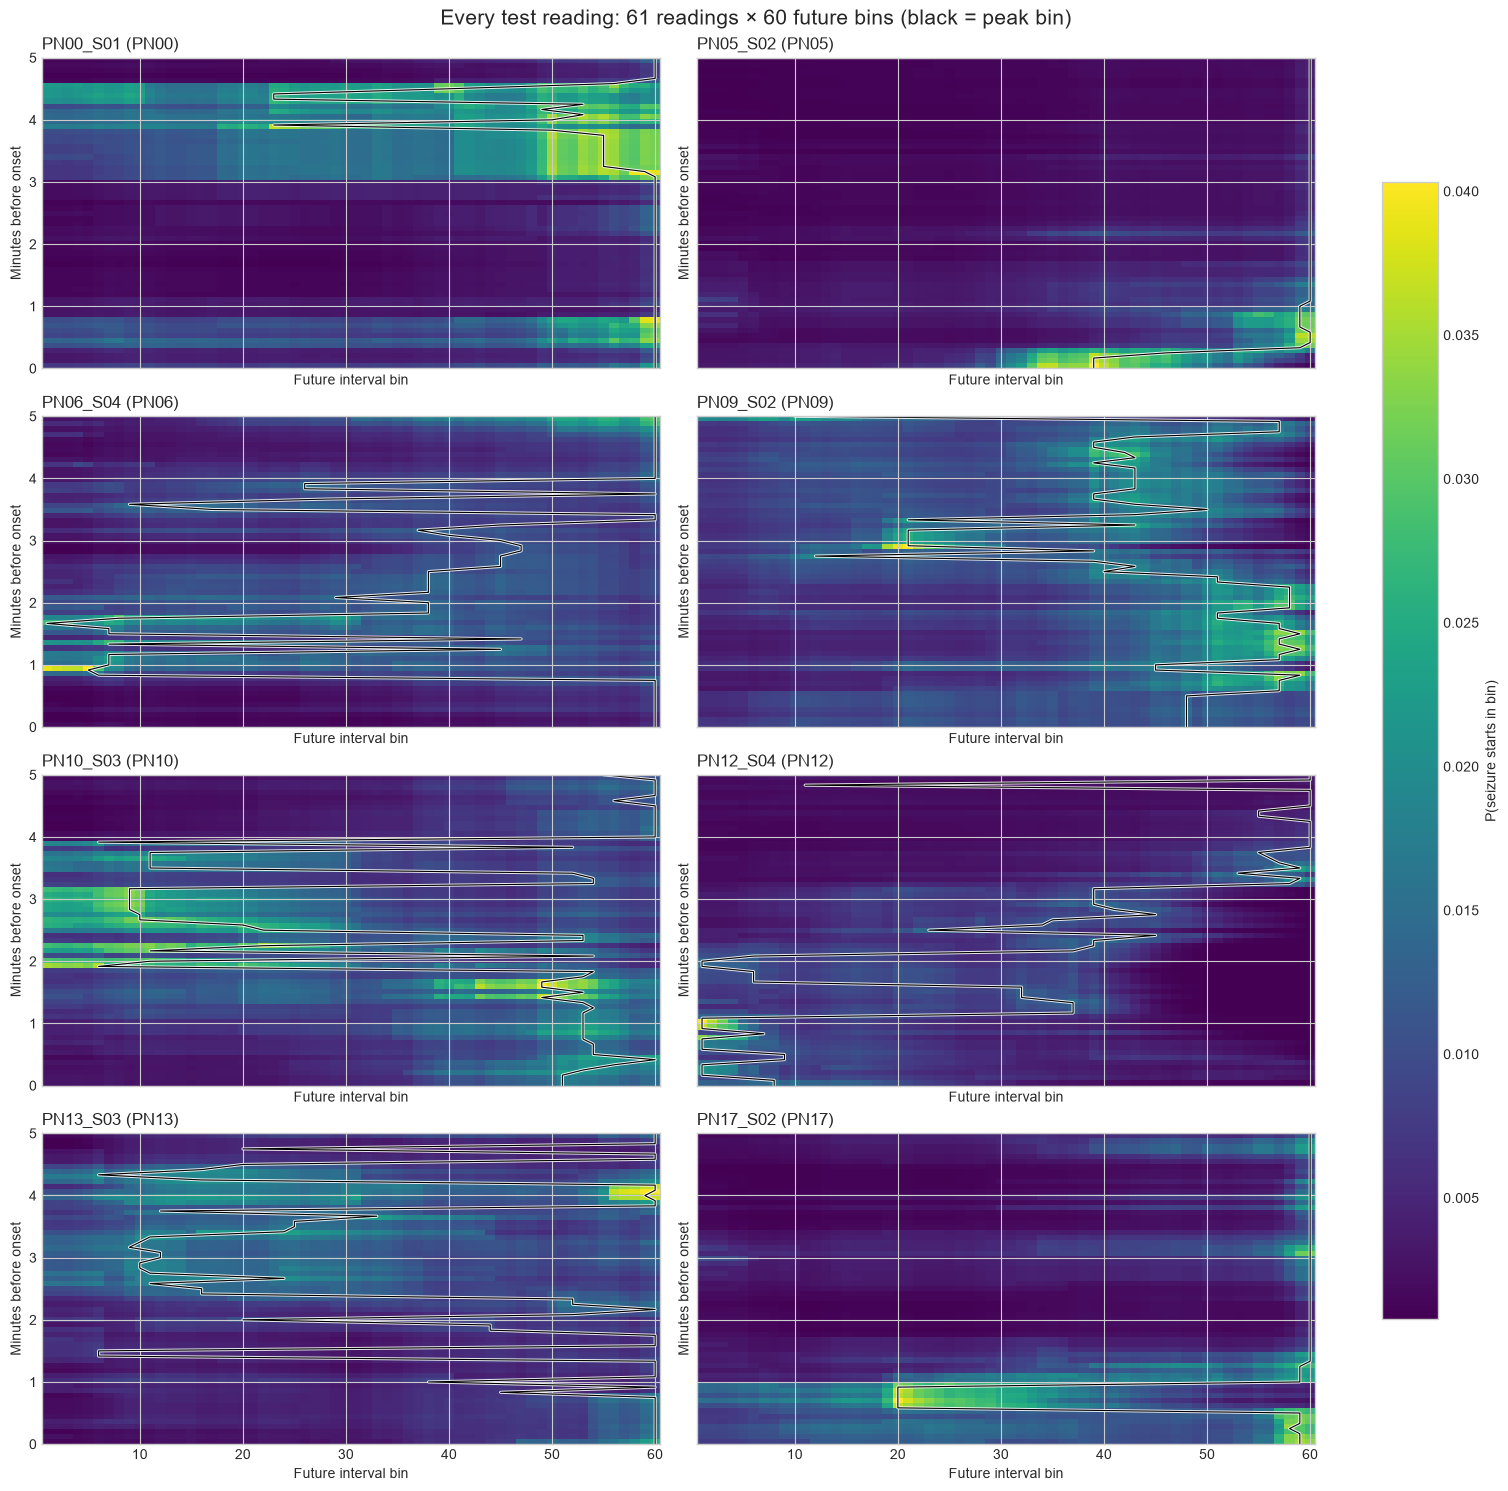

Saved public notebook graph: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast\test_reading_probability_heatmaps.png


In [7]:
test_long = reading_probabilities.loc[
    reading_probabilities["dataset_split"].eq("test")
].copy()
test_peaks = peak_readings.loc[
    peak_readings["dataset_split"].eq("test")
].copy()

n_test = len(test_event_ids)
ncols = 2
nrows = int(np.ceil(n_test / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 3.7 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
image = None
for axis, event_id in zip(axes, test_event_ids, strict=False):
    event_long = test_long.loc[
        test_long["source_event_id"].eq(event_id)
    ]
    probability_grid = (
        event_long.pivot(
            index="reading_index",
            columns="future_bin",
            values="onset_probability",
        )
        .sort_index()
        .to_numpy()
    )
    event_peak = test_peaks.loc[
        test_peaks["source_event_id"].eq(event_id)
    ].sort_values("reading_index")
    image = axis.imshow(
        probability_grid,
        aspect="auto",
        origin="upper",
        interpolation="nearest",
        extent=[
            0.5,
            config.n_bins + 0.5,
            0,
            M_MINUTES,
        ],
        cmap="viridis",
    )
    axis.plot(
        event_peak["peak_bin"],
        event_peak["minutes_before_onset"],
        color="white",
        linewidth=2.2,
        alpha=0.9,
    )
    axis.plot(
        event_peak["peak_bin"],
        event_peak["minutes_before_onset"],
        color="black",
        linewidth=0.8,
    )
    patient = event_peak["patient_id"].iloc[0]
    axis.set_title(f"{event_id} ({patient})", loc="left")
    axis.set_ylabel("Minutes before onset")
    axis.set_xlabel("Future interval bin")
for axis in axes[n_test:]:
    axis.set_visible(False)
colorbar = fig.colorbar(
    image,
    ax=[axis for axis in axes[:n_test]],
    shrink=0.82,
    label="P(seizure starts in bin)",
)
fig.suptitle(
    f"Every test reading: {config.reading_count} readings × "
    f"{config.n_bins} future bins (black = peak bin)",
    fontsize=15,
)
heatmap_path = paths["results"] / "test_reading_probability_heatmaps.png"
fig.savefig(heatmap_path, dpi=170, bbox_inches="tight")
plt.show()
print(f"Saved public notebook graph: {heatmap_path}")


## Rolling-boundary verification and computational complexity

In [8]:
example = manifest.loc[
    manifest["dataset_split"].eq("test")
    & manifest["episode_type"].eq("preictal")
].iloc[0]
engine = rsf.RollingForecastEngine(
    model,
    example["edf_path"],
    example["anchor_seconds"],
    config,
    replay_duration_seconds=config.pre_onset_seconds,
)
state_start = engine.advance_to(example["anchor_seconds"])
state_inside = engine.advance_to(
    example["anchor_seconds"] + config.bin_seconds - 0.1
)
state_next = engine.advance_to(
    example["anchor_seconds"] + config.bin_seconds
)
state_onset = engine.advance_to(example["event_onset_seconds"])

assert state_inside["updated"] is False
assert state_start["forecast_bins"] == config.n_bins
assert state_next["forecast_bins"] == config.n_bins
assert state_onset["forecast_bins"] == config.n_bins
assert state_next["expired_absolute_bin"] == 1
assert state_next["appended_absolute_bin"] == config.n_bins + 1
assert np.isclose(
    state_onset["horizon_end_seconds"],
    example["event_onset_seconds"] + config.horizon_seconds,
)
assert engine.optimization_stats["online_edf_reads"] == 0
assert engine.optimization_stats["online_model_calls"] == 0

boundary_check = pd.DataFrame(
    [
        {
            "call": "-m",
            "updated": state_start["updated"],
            "step": state_start["episode_step"],
            "future_bins": state_start["forecast_bins"],
            "first_absolute_bin": int(
                state_start["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_start["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
        {
            "call": "inside first interval",
            "updated": state_inside["updated"],
            "step": state_inside["episode_step"],
            "future_bins": state_inside["forecast_bins"],
            "first_absolute_bin": int(
                state_inside["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_inside["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
        {
            "call": "next boundary",
            "updated": state_next["updated"],
            "step": state_next["episode_step"],
            "future_bins": state_next["forecast_bins"],
            "first_absolute_bin": int(
                state_next["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_next["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
        {
            "call": "onset boundary",
            "updated": state_onset["updated"],
            "step": state_onset["episode_step"],
            "future_bins": state_onset["forecast_bins"],
            "first_absolute_bin": int(
                state_onset["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_onset["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
    ]
)
display(boundary_check)
display(pd.Series(engine.optimization_stats, name="value").to_frame())


,call,updated,step,future_bins,first_absolute_bin,last_absolute_bin
0,-m,True,0,60,1,60
1,inside first interval,False,0,60,1,60
2,next boundary,True,1,60,2,61
3,onset boundary,True,60,60,61,120


,value
forecast_states_precomputed,61.000000
eeg_seconds_processed_once,420.000000
naive_eeg_seconds_if_full_context_reread,7320.000000
raw_signal_work_reduction_factor,17.428571
online_edf_reads,0.000000
online_model_calls,0.000000
precomputation_seconds,1.091599


Let \(S\) be seizures, \(U=m/i+1\) readings per seizure, \(K=r/i\)
future bins, \(C\) EEG channels, \(f_s\) sample rate, \(F\) aggregated
features, and \(T\) the number of boosting trees.

- Re-reading two minutes for every state would cost
  \(O(S U C f_s\,120)\) signal work.
- The rolling engine reads each contiguous replay once:
  \(O(S C f_s(120+m))\), then caches overlapping contexts.
- Feature aggregation is \(O(SUF)\).
- Batched hazard inference is \(O(SUKT)\) up to tree depth.
- A cached boundary update is \(O(1)\); displaying its full graph is
  necessarily \(O(K)\).
- Stored complete probabilities use \(O(SUK)\) space. The peak matrix
  alone uses \(O(SU)\), but must not replace the full distribution for
  scoring.

The notebook also reuses all pre-onset cached training features and reads
only one additional two-minute context per seizure for the requested
onset-time row.


## Model interpretability

Two model-agnostic explanations are reported:

1. **Global permutation importance:** each EEG feature is shuffled in
   the validation set. The importance is the resulting increase in
   categorical negative log likelihood. Positive values indicate that
   the fitted model used the feature.
2. **Local counterfactual sensitivity:** for the highest-risk test
   landmark, one feature at a time is replaced by its training median.
   Positive risk change means the observed value raised the forecast;
   negative change means it lowered the forecast.

These explanations are descriptive. Correlated EEG features can divide
or mask permutation importance, and one-feature replacements are neither
additive Shapley values nor causal effects.


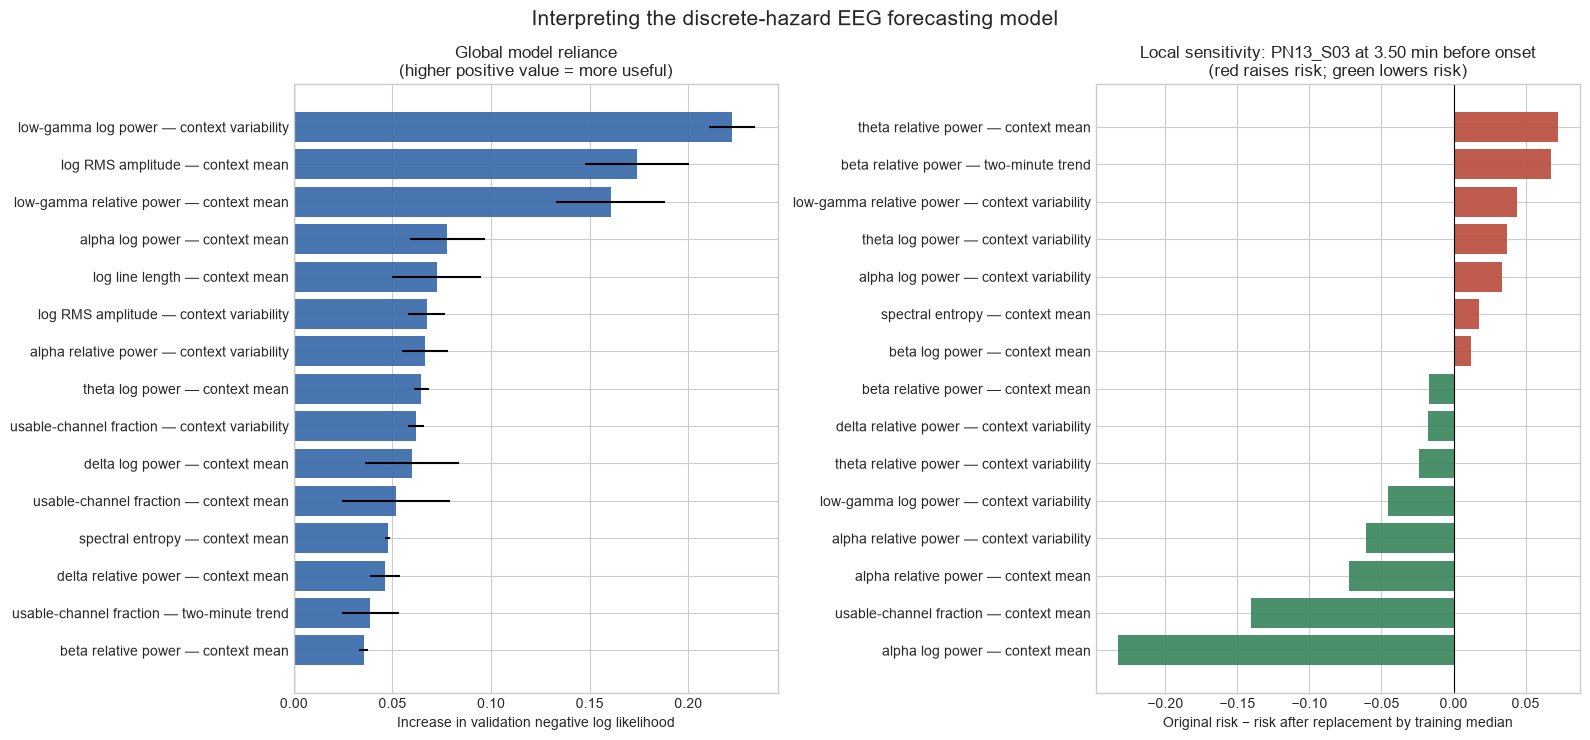

### Top global validation features

feature,readable_feature,importance_nll_increase,importance_std,baseline_validation_nll,repeats
log_power_low_gamma_std,low-gamma log power — context variability,0.222143,0.011642,2.9645,2
log_rms_mean,log RMS amplitude — context mean,0.173900,0.026292,2.9645,2
relative_low_gamma_mean,low-gamma relative power — context mean,0.160687,0.027725,2.9645,2
log_power_alpha_mean,alpha log power — context mean,0.077783,0.018975,2.9645,2
log_line_length_mean,log line length — context mean,0.072491,0.022514,2.9645,2
log_rms_std,log RMS amplitude — context variability,0.067289,0.009244,2.9645,2
relative_alpha_std,alpha relative power — context variability,0.066451,0.011760,2.9645,2
log_power_theta_mean,theta log power — context mean,0.064657,0.003827,2.9645,2
usable_channel_fraction_std,usable-channel fraction — context variability,0.061952,0.003874,2.9645,2
log_power_delta_mean,delta log power — context mean,0.059942,0.023637,2.9645,2


### Local explanation for a representative test landmark
Event: **PN13_S03**; patient: **PN13**; time before onset: **3.50 min**; forecast event risk: **0.5013**.

feature,readable_feature,observed_value,training_median,original_event_risk,counterfactual_event_risk,risk_change_when_observed,absolute_risk_change
log_power_alpha_mean,alpha log power — context mean,0.418152,0.6513,0.5013,0.7343,-0.233006,0.233006
usable_channel_fraction_mean,usable-channel fraction — context mean,0.935484,0.998656,0.5013,0.6418,-0.140494,0.140494
relative_alpha_mean,alpha relative power — context mean,0.0529803,0.0769185,0.5013,0.5739,-0.072549,0.072549
relative_theta_mean,theta relative power — context mean,0.0987494,0.112258,0.5013,0.4288,+0.072521,0.072521
relative_beta_slope,beta relative power — two-minute trend,-0.000141242,-3.23236e-06,0.5013,0.4335,+0.067857,0.067857
relative_alpha_std,alpha relative power — context variability,0.0203076,0.0312939,0.5013,0.5623,-0.060958,0.060958
log_power_low_gamma_std,low-gamma log power — context variability,0.313652,0.191967,0.5013,0.5467,-0.045389,0.045389
relative_low_gamma_std,low-gamma relative power — context variability,0.0468987,0.0207351,0.5013,0.4574,+0.043890,0.043890
log_power_theta_std,theta log power — context variability,0.164128,0.189682,0.5013,0.4644,+0.036970,0.036970
log_power_alpha_std,alpha log power — context variability,0.114513,0.176904,0.5013,0.4678,+0.033559,0.033559


Computed global and local explanations in 12.7 seconds.


In [9]:
started = time.time()
global_importance = rsf.permutation_feature_importance(
    model,
    validation,
    config,
    n_repeats=2,
    random_seed=RANDOM_SEED,
)

representative_index = int(
    (test_predictions["event_risk"] - 0.5).abs().argmin()
)
explained_prediction = test_predictions.iloc[representative_index]
explained_reading = test.reset_index(drop=True).iloc[
    [representative_index]
]
local_explanation = rsf.local_counterfactual_explanation(
    model,
    explained_reading,
    train,
    config,
)
interpretation_seconds = time.time() - started

global_importance.to_csv(
    paths["results"] / "global_permutation_importance.csv", index=False
)
local_explanation.to_csv(
    paths["results"] / "local_counterfactual_explanation.csv", index=False
)

assert len(global_importance) == len(rsf.MODEL_FEATURE_COLUMNS)
assert len(local_explanation) == len(rsf.MODEL_FEATURE_COLUMNS)
assert np.isfinite(
    global_importance[
        ["importance_nll_increase", "importance_std"]
    ].to_numpy()
).all()
assert np.isfinite(
    local_explanation[
        ["counterfactual_event_risk", "risk_change_when_observed"]
    ].to_numpy()
).all()

top_global = global_importance.head(15).sort_values(
    "importance_nll_increase"
)
top_local = local_explanation.head(15).sort_values(
    "risk_change_when_observed"
)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
axes[0].barh(
    top_global["readable_feature"],
    top_global["importance_nll_increase"],
    xerr=top_global["importance_std"],
    color="#3567A9",
    alpha=0.9,
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set(
    xlabel="Increase in validation negative log likelihood",
    title="Global model reliance\n(higher positive value = more useful)",
)

local_colors = np.where(
    top_local["risk_change_when_observed"] >= 0,
    "#B84A3A",
    "#35845B",
)
axes[1].barh(
    top_local["readable_feature"],
    top_local["risk_change_when_observed"],
    color=local_colors,
    alpha=0.9,
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(
    xlabel="Original risk − risk after replacement by training median",
    title=(
        f"Local sensitivity: {explained_prediction['source_event_id']} "
        f"at {explained_prediction['time_to_event_seconds'] / 60:.2f} min "
        "before onset\n(red raises risk; green lowers risk)"
    ),
)
fig.suptitle(
    "Interpreting the discrete-hazard EEG forecasting model",
    fontsize=15,
)
fig.tight_layout()
interpretability_path = (
    paths["results"] / "model_interpretability.png"
)
fig.savefig(interpretability_path, dpi=170, bbox_inches="tight")
plt.show()

display(Markdown("### Top global validation features"))
display(
    global_importance.head(15).style.format(
        {
            "importance_nll_increase": "{:.6f}",
            "importance_std": "{:.6f}",
            "baseline_validation_nll": "{:.4f}",
        }
    ).hide(axis="index")
)
display(Markdown(
    "### Local explanation for a representative test landmark\n"
    f"Event: **{explained_prediction['source_event_id']}**; "
    f"patient: **{explained_prediction['patient_id']}**; "
    f"time before onset: **"
    f"{explained_prediction['time_to_event_seconds'] / 60:.2f} min**; "
    f"forecast event risk: **{explained_prediction['event_risk']:.4f}**."
))
display(
    local_explanation.head(15).style.format(
        {
            "observed_value": "{:.6g}",
            "training_median": "{:.6g}",
            "original_event_risk": "{:.4f}",
            "counterfactual_event_risk": "{:.4f}",
            "risk_change_when_observed": "{:+.6f}",
            "absolute_risk_change": "{:.6f}",
        }
    ).hide(axis="index")
)
print(
    f"Computed global and local explanations in "
    f"{interpretation_seconds:.1f} seconds."
)


## Readable artifact inventory and completion checks

In [10]:
artifact_purposes = {
    "seizure_split_allocation.csv": "exact random seed-42 seizure assignment",
    "episode_manifest.csv": "all selected seizure/control EDF episodes",
    "validation_metrics.csv": "validation performance",
    "test_metrics.csv": "held-out test performance",
    "validation_landmark_probabilities.csv": "all validation landmark forecasts",
    "test_landmark_probabilities.csv": "all test landmark forecasts",
    "all_seizure_reading_probabilities.csv": "every reading × every future-bin probability",
    "all_seizure_peak_readings.csv": "one peak bin and probability per reading",
    "all_seizure_peak_bin_matrix.csv": "47 seizure columns with (bin, probability) entries",
    "test_peak_bin_matrix.csv": "test-only readable peak matrix",
    "test_reading_probability_heatmaps.png": "all test reading probability graphs",
    "rolling_discrete_hazard_model.joblib": "trained model, parameters, split, and metrics",
    "global_permutation_importance.csv": "global validation feature importance",
    "local_counterfactual_explanation.csv": "local test-forecast sensitivity",
    "model_interpretability.png": "global and local interpretation plots",
}
artifact_rows = []
for artifact in sorted(paths["results"].iterdir()):
    if artifact.is_file():
        artifact_rows.append(
            {
                "file": artifact.name,
                "size_mb": round(artifact.stat().st_size / 1e6, 3),
                "purpose": artifact_purposes.get(
                    artifact.name, "prior/generated analysis artifact"
                ),
            }
        )
artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(
    paths["results"] / "ARTIFACT_INVENTORY.csv", index=False
)
display(artifact_inventory)

completion = pd.DataFrame(
    {
        "requirement": [
            "exact seizure quotas",
            "seizures disjoint across splits",
            "two-minute causal EEG context",
            "configurable m, r, and i",
            "r/i probabilities at every reading",
            "first reading at -m and last at onset",
            "peak matrix entries are (bin, probability)",
            "all probability mass sums to one",
            "all test reading graphs saved and displayed",
        ],
        "passed": [
            True,
            not seizure_allocation["source_event_id"].duplicated().any(),
            config.context_seconds == 120,
            True,
            reading_probabilities.groupby(
                ["source_event_id", "reading_index"]
            ).size().eq(config.n_bins).all(),
            peak_readings.groupby("source_event_id")[
                "minutes_before_onset"
            ].agg(["max", "min"]).eq(
                pd.Series({"max": M_MINUTES, "min": 0.0})
            ).all().all(),
            peak_readings["peak_entry"].str.match(
                r"^\(\d+, \d+\.\d{6}\)$"
            ).all(),
            np.allclose(
                mass_check["event_mass"]
                + mass_check["no_event_probability"],
                1.0,
                atol=1e-8,
            ),
            heatmap_path.exists(),
        ],
    }
)
assert completion["passed"].all(), completion
display(completion)
display(
    Markdown(
        f"**Complete.** The model was trained on 35 seizures, validated "
        f"on 4, and tested on 8. Every one of the 47 seizures has "
        f"{config.reading_count} requested readings and every reading has "
        f"{config.n_bins} future-bin probabilities plus explicit no-event "
        f"mass. Outputs are in `{paths['results']}`."
    )
)


,file,size_mb,purpose
0,all_seizure_peak_bin_matrix.csv,0.050,"47 seizure columns with (bin, probability) ent..."
1,all_seizure_peak_readings.csv,0.453,one peak bin and probability per reading
2,all_seizure_reading_probabilities.csv,29.205,every reading × every future-bin probability
3,ARTIFACT_INVENTORY.csv,0.002,prior/generated analysis artifact
4,development_warning_curve.csv,0.012,prior/generated analysis artifact
5,episode_manifest.csv,0.017,all selected seizure/control EDF episodes
6,forecast_evaluation.png,0.090,prior/generated analysis artifact
7,global_permutation_importance.csv,0.007,global validation feature importance
8,holdout_landmark_probabilities.csv,2.676,prior/generated analysis artifact
9,holdout_metrics.csv,0.001,prior/generated analysis artifact


,requirement,passed
0,exact seizure quotas,True
1,seizures disjoint across splits,True
2,two-minute causal EEG context,True
3,"configurable m, r, and i",True
4,r/i probabilities at every reading,True
5,first reading at -m and last at onset,True
6,"peak matrix entries are (bin, probability)",True
7,all probability mass sums to one,True
8,all test reading graphs saved and displayed,True


**Complete.** The model was trained on 35 seizures, validated on 4, and tested on 8. Every one of the 47 seizures has 61 requested readings and every reading has 60 future-bin probabilities plus explicit no-event mass. Outputs are in `C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast`.

## Final executed results

This section collects the important outputs in one place inside
this notebook: experiment parameters, exact split sizes, held-out
test metrics, the complete test peak-bin matrix, the probability
graph, and the validation checklist.


### Parameters

symbol,value,meaning
m,5 min,first reading before seizure onset
r,5 min,future horizon at every reading
i,5 s,reading step and future-bin width
context,120 s,causal EEG history retained
r/i bins,60,probability bins per reading
readings,61,"from -m through onset, inclusive"


### Exact split sizes

split,seizures,interictal controls,landmarks,patients
train,35,35,4200,13
validation,4,4,480,4
test,8,8,960,8


### Held-out test metrics

metric,value,interpretation
negative log likelihood,3.7283,Lower is better; proper score for the observed bin/no-event class.
multicategory Brier score,0.9704,Lower is better; probability error across 60 bins plus no-event.
multicategory Brier skill score,-0.3010,Above 0 improves on the development-set class-frequency forecast.
integrated survival Brier score,0.2534,Lower is better; mean survival-probability error across 5-minute horizon.
5-minute AUROC,0.2824,Discrimination only; does not assess calibration.
5-minute average precision,0.4370,Ranking metric sensitive to event prevalence.
conditional timing MAE (seconds),74.2883,Error of expected onset time among seizure landmarks.
seizure sensitivity,0.5000,Fraction of seizure episodes with at least one warning.
time in warning,0.1562,Fraction of evaluated 5-second landmarks under warning.
false alarms per hour,13.5000,Rising warning edges in interictal episodes per monitored hour.


### Test peak-bin matrix
Every entry is `(highest-probability future bin, probability)`. Rows run from `m` minutes before onset through the onset boundary.

reading_index,minutes_before_onset,PN00_S01,PN05_S02,PN06_S04,PN09_S02,PN10_S03,PN12_S04,PN13_S03,PN17_S02
0,5.000000,"(60, 0.009855)","(60, 0.004699)","(60, 0.018447)","(10, 0.033986)","(55, 0.008813)","(60, 0.007981)","(60, 0.009918)","(60, 0.011219)"
1,4.916667,"(60, 0.006079)","(60, 0.004729)","(60, 0.017360)","(57, 0.023998)","(60, 0.011088)","(60, 0.007816)","(60, 0.006949)","(60, 0.020036)"
2,4.833333,"(60, 0.005767)","(60, 0.005115)","(60, 0.013572)","(57, 0.025094)","(60, 0.012310)","(11, 0.005550)","(60, 0.005331)","(60, 0.023181)"
3,4.750000,"(60, 0.005960)","(60, 0.005107)","(60, 0.011462)","(57, 0.028691)","(60, 0.010688)","(60, 0.004581)","(20, 0.004894)","(60, 0.022972)"
4,4.666667,"(60, 0.008550)","(60, 0.004102)","(60, 0.009220)","(43, 0.034522)","(60, 0.009852)","(60, 0.006567)","(60, 0.005792)","(60, 0.013960)"
5,4.583333,"(56, 0.023308)","(60, 0.004101)","(60, 0.007944)","(39, 0.032851)","(56, 0.009518)","(60, 0.008501)","(60, 0.006442)","(60, 0.008879)"
6,4.500000,"(40, 0.022129)","(60, 0.005456)","(60, 0.007949)","(39, 0.041756)","(60, 0.008420)","(60, 0.006316)","(20, 0.009604)","(60, 0.008443)"
7,4.416667,"(23, 0.018496)","(60, 0.005500)","(60, 0.007389)","(42, 0.043876)","(60, 0.011509)","(55, 0.014707)","(16, 0.012938)","(60, 0.010764)"
8,4.333333,"(23, 0.018861)","(60, 0.004838)","(60, 0.006819)","(43, 0.035015)","(60, 0.011583)","(55, 0.013823)","(6, 0.012982)","(60, 0.008544)"
9,4.250000,"(53, 0.021401)","(60, 0.004440)","(60, 0.008254)","(39, 0.039650)","(60, 0.011541)","(60, 0.015707)","(16, 0.013300)","(60, 0.020584)"


### Every test reading probability graph

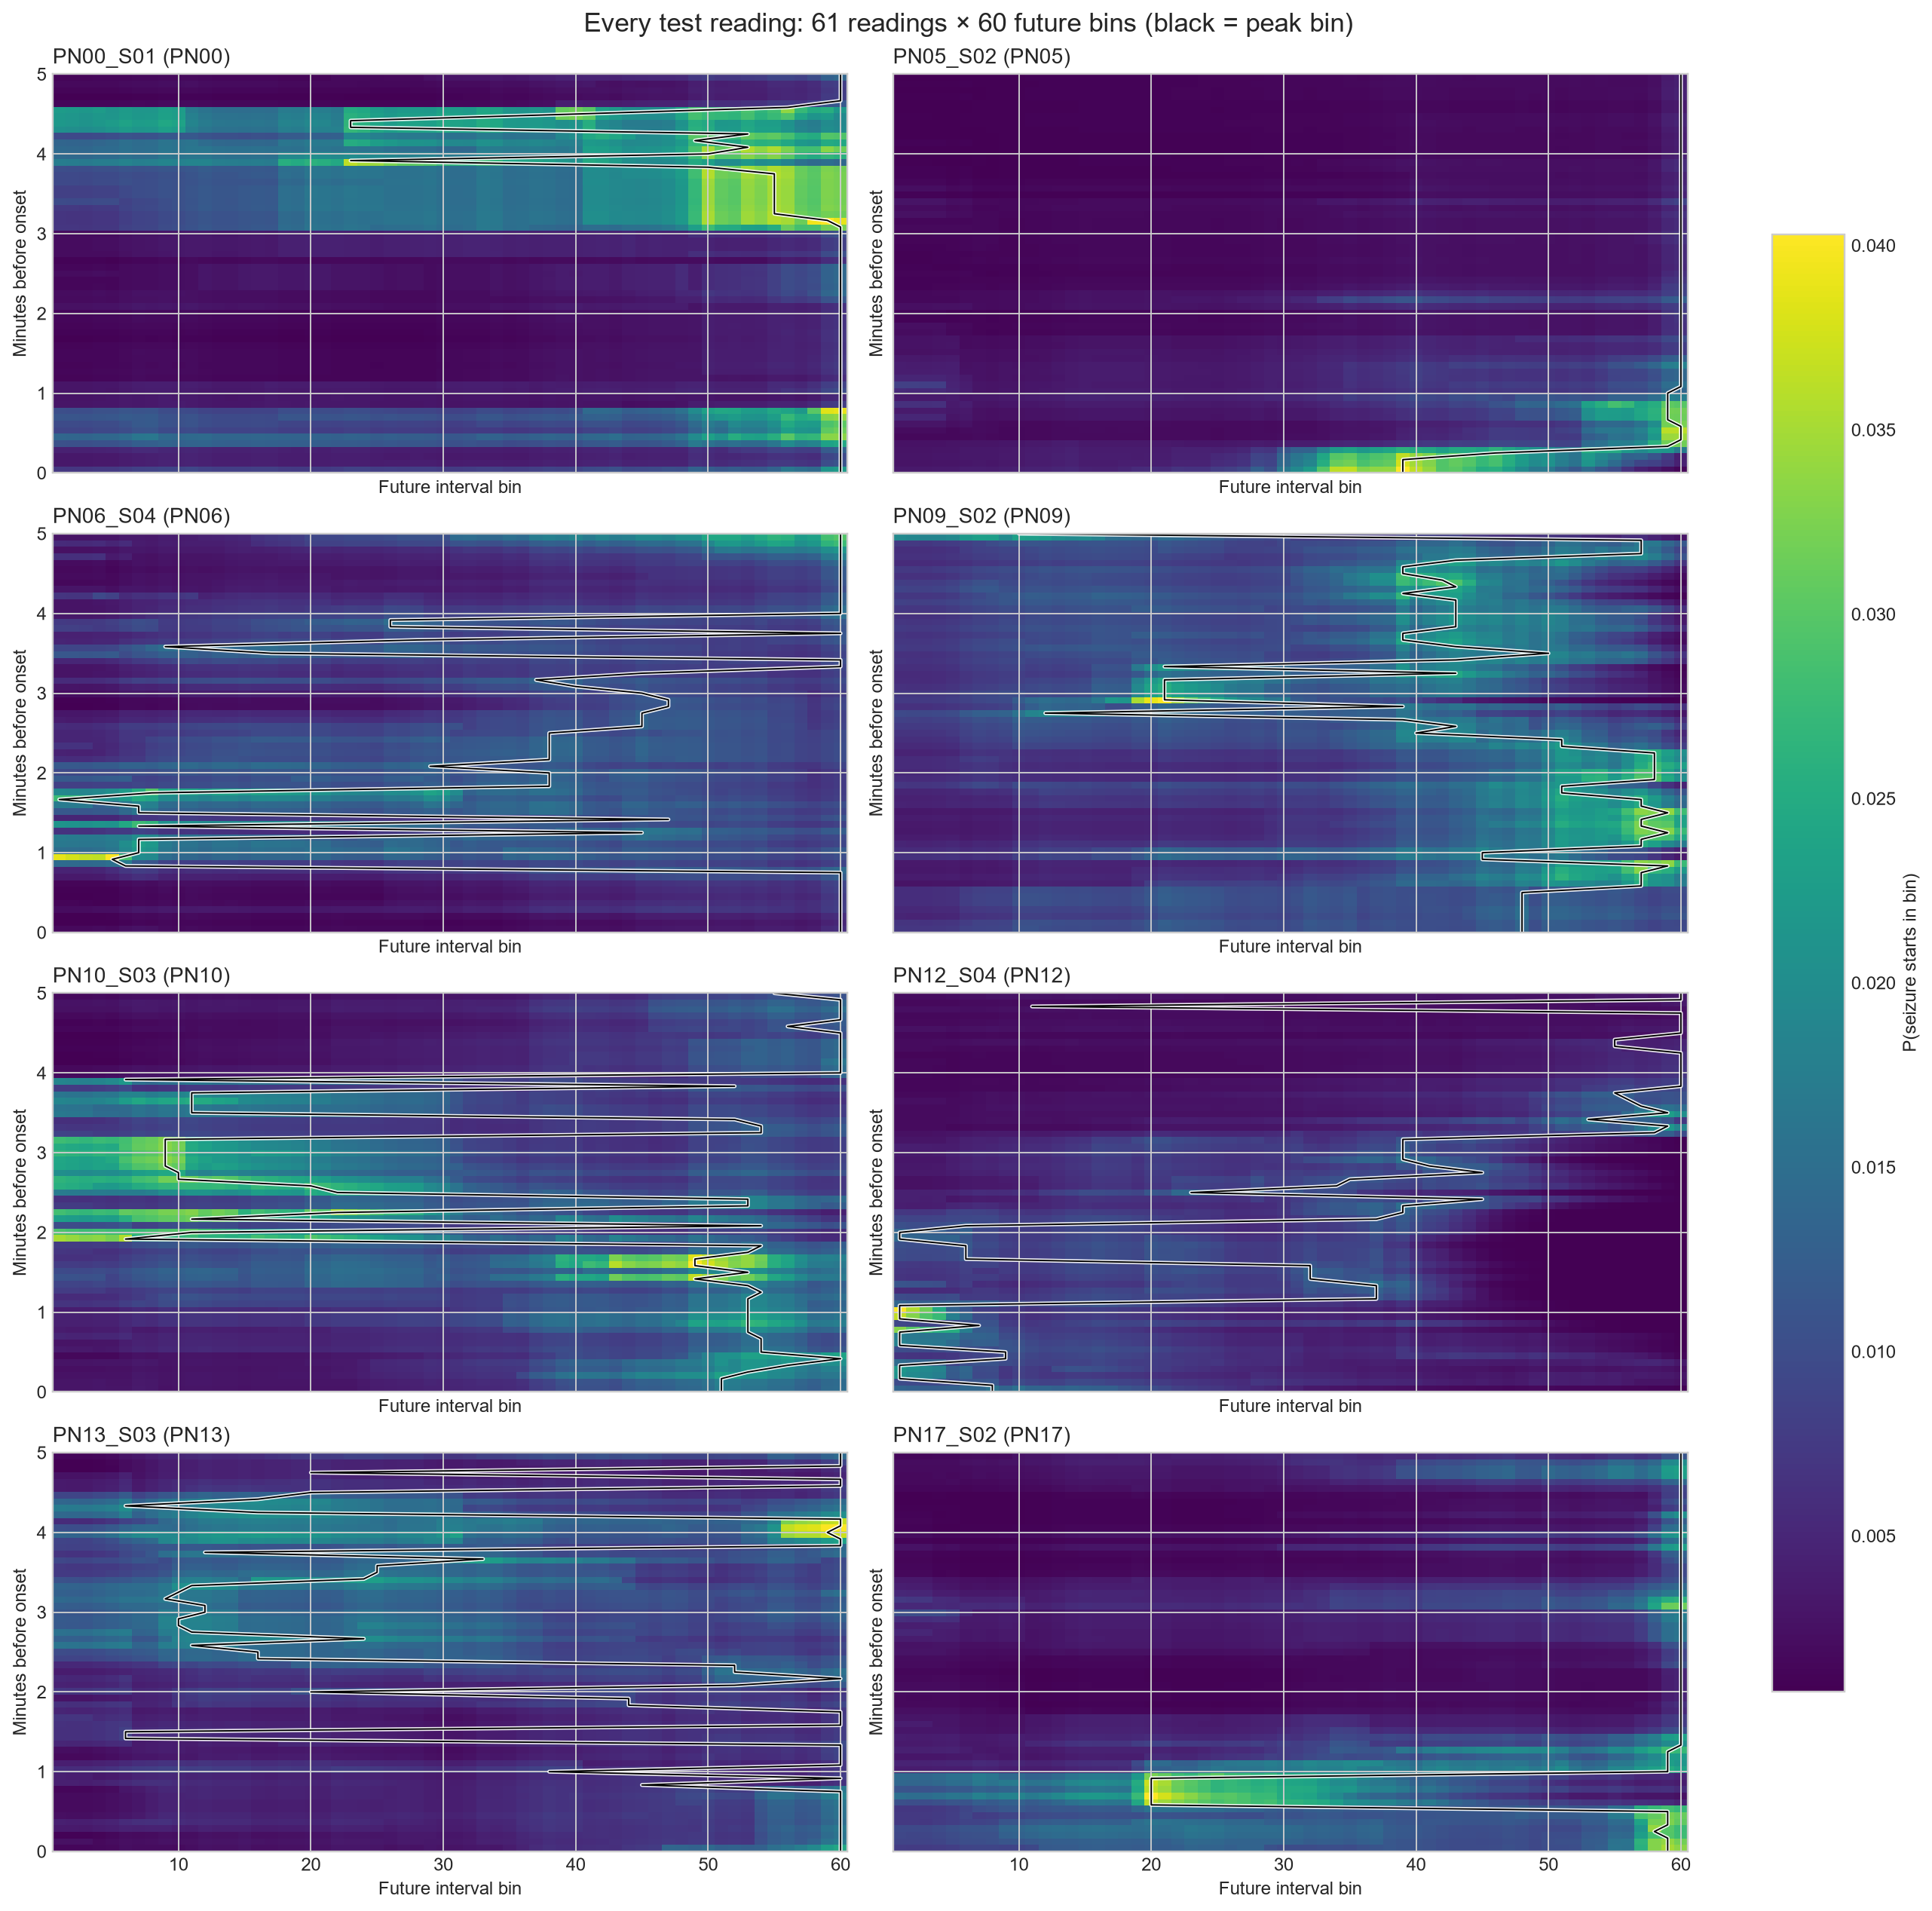

### Model interpretation

feature,readable_feature,importance_nll_increase,importance_std,baseline_validation_nll,repeats
log_power_low_gamma_std,low-gamma log power — context variability,0.222143,0.011642,2.964495,2
log_rms_mean,log RMS amplitude — context mean,0.173900,0.026292,2.964495,2
relative_low_gamma_mean,low-gamma relative power — context mean,0.160687,0.027725,2.964495,2
log_power_alpha_mean,alpha log power — context mean,0.077783,0.018975,2.964495,2
log_line_length_mean,log line length — context mean,0.072491,0.022514,2.964495,2
log_rms_std,log RMS amplitude — context variability,0.067289,0.009244,2.964495,2
relative_alpha_std,alpha relative power — context variability,0.066451,0.011760,2.964495,2
log_power_theta_mean,theta log power — context mean,0.064657,0.003827,2.964495,2
usable_channel_fraction_std,usable-channel fraction — context variability,0.061952,0.003874,2.964495,2
log_power_delta_mean,delta log power — context mean,0.059942,0.023637,2.964495,2


feature,readable_feature,observed_value,training_median,original_event_risk,counterfactual_event_risk,risk_change_when_observed,absolute_risk_change
log_power_alpha_mean,alpha log power — context mean,0.418152,0.651300,0.501325,0.7343,-0.233006,0.233006
usable_channel_fraction_mean,usable-channel fraction — context mean,0.935484,0.998656,0.501325,0.6418,-0.140494,0.140494
relative_alpha_mean,alpha relative power — context mean,0.052980,0.076919,0.501325,0.5739,-0.072549,0.072549
relative_theta_mean,theta relative power — context mean,0.098749,0.112258,0.501325,0.4288,+0.072521,0.072521
relative_beta_slope,beta relative power — two-minute trend,-0.000141,-0.000003,0.501325,0.4335,+0.067857,0.067857
relative_alpha_std,alpha relative power — context variability,0.020308,0.031294,0.501325,0.5623,-0.060958,0.060958
log_power_low_gamma_std,low-gamma log power — context variability,0.313652,0.191967,0.501325,0.5467,-0.045389,0.045389
relative_low_gamma_std,low-gamma relative power — context variability,0.046899,0.020735,0.501325,0.4574,+0.043890,0.043890
log_power_theta_std,theta log power — context variability,0.164128,0.189682,0.501325,0.4644,+0.036970,0.036970
log_power_alpha_std,alpha log power — context variability,0.114513,0.176904,0.501325,0.4678,+0.033559,0.033559


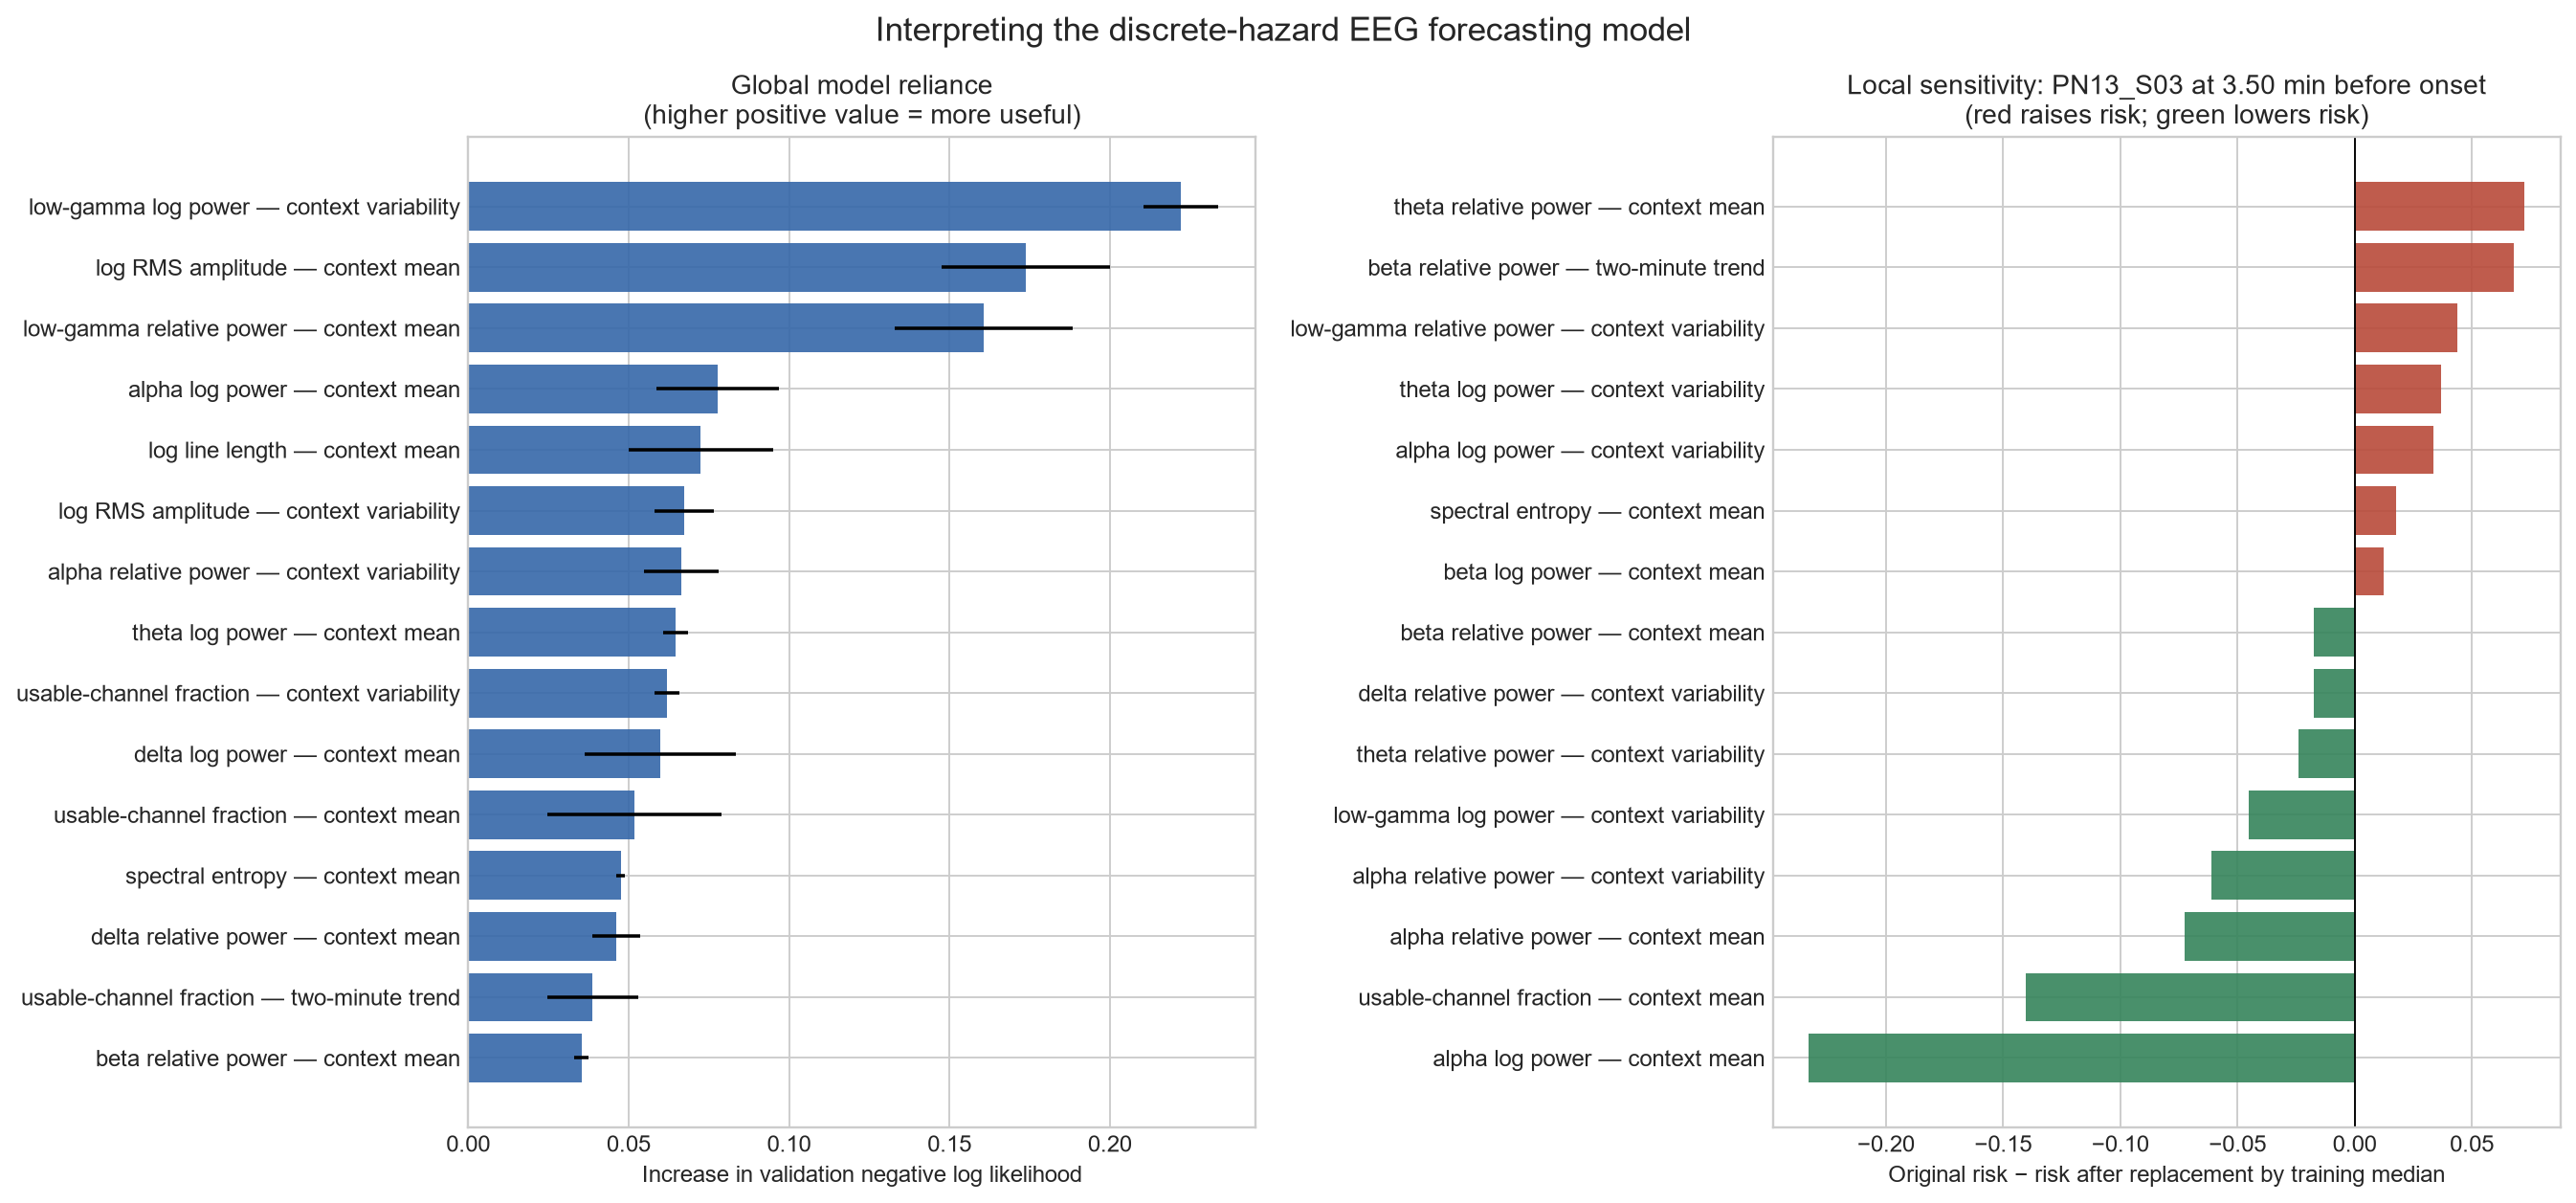

### Validation checklist

requirement,passed
exact seizure quotas,True
seizures disjoint across splits,True
two-minute causal EEG context,True
"configurable m, r, and i",True
r/i probabilities at every reading,True
first reading at -m and last at onset,True
"peak matrix entries are (bin, probability)",True
all probability mass sums to one,True
all test reading graphs saved and displayed,True


Notebook complete: 47 disjoint seizures, 61 readings per seizure, 60 future bins per reading, 172,020 saved bin probabilities.


In [11]:
from IPython.display import Image

display(Markdown("### Parameters"))
display(parameter_table.style.hide(axis="index"))

display(Markdown("### Exact split sizes"))
display(split_summary.style.hide(axis="index"))

display(Markdown("### Held-out test metrics"))
display(test_metrics.style.format({"value": "{:.4f}"}).hide(axis="index"))

display(Markdown(
    "### Test peak-bin matrix\n"
    "Every entry is `(highest-probability future bin, probability)`. "
    "Rows run from `m` minutes before onset through the onset boundary."
))
display(test_peak_matrix.style.hide(axis="index"))

display(Markdown("### Every test reading probability graph"))
display(Image(filename=str(heatmap_path)))

display(Markdown("### Model interpretation"))
display(global_importance.head(15).style.format({
    "importance_nll_increase": "{:.6f}",
    "importance_std": "{:.6f}",
}).hide(axis="index"))
display(local_explanation.head(15).style.format({
    "risk_change_when_observed": "{:+.6f}",
    "counterfactual_event_risk": "{:.4f}",
}).hide(axis="index"))
display(Image(filename=str(interpretability_path)))

display(Markdown("### Validation checklist"))
display(completion.style.hide(axis="index"))

print(
    f"Notebook complete: {len(seizure_allocation)} disjoint seizures, "
    f"{config.reading_count} readings per seizure, "
    f"{config.n_bins} future bins per reading, "
    f"{len(reading_probabilities):,} saved bin probabilities."
)
